INITIAL STATE (Iteration 0)
  m = [-1.  2.],  b = [1. 1.]
  y_hat = [ 6. 17.]
  MSE   = 61.000000

ITERATION 1
  y_hat            = [ 6. 17.]
  errors (y_hat-y) = [ 1. 11.]
  dJ/dm (SciPy)    = [ 45.00000105 113.00000534]
  dJ/dm (chain)    = [ 45. 113.]   <- should match
  dJ/db (SciPy)    = [ 1.00000008 11.00000019]
  dJ/db (chain)    = [ 1. 11.]   <- should match
  updated m        = [-1.45000001  0.86999995]
  updated b        = [0.99 0.89]
  MSE after update = 6.503302

ITERATION 2
  y_hat            = [2.14999983 3.78999942]
  errors (y_hat-y) = [-2.85000017 -2.21000058]
  dJ/dm (SciPy)    = [-11.69000164 -30.65000084]
  dJ/dm (chain)    = [-11.69000248 -30.6500063 ]   <- should match
  dJ/db (SciPy)    = [-2.85000012 -2.21000053]
  dJ/db (chain)    = [-2.85000017 -2.21000058]   <- should match
  updated m        = [-1.33309999  1.17649995]
  updated b        = [1.0185 0.9121]
  MSE after update = 2.497400

ITERATION 3
  y_hat            = [3.21489987 7.34469958]
  errors (y_hat-

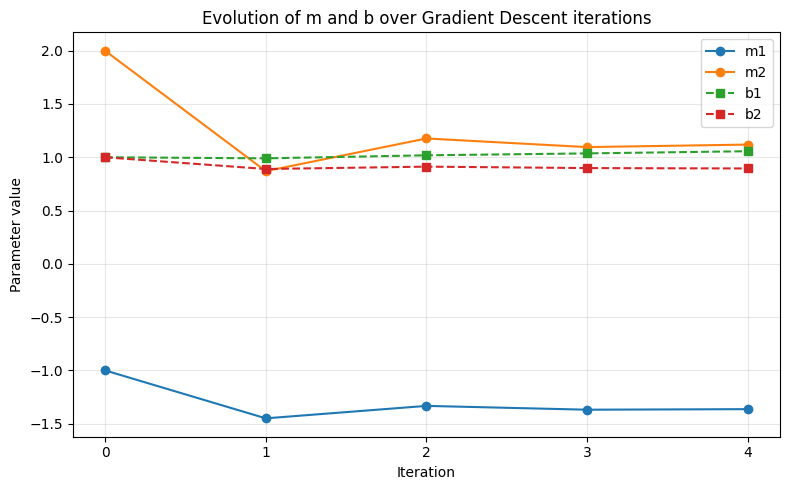

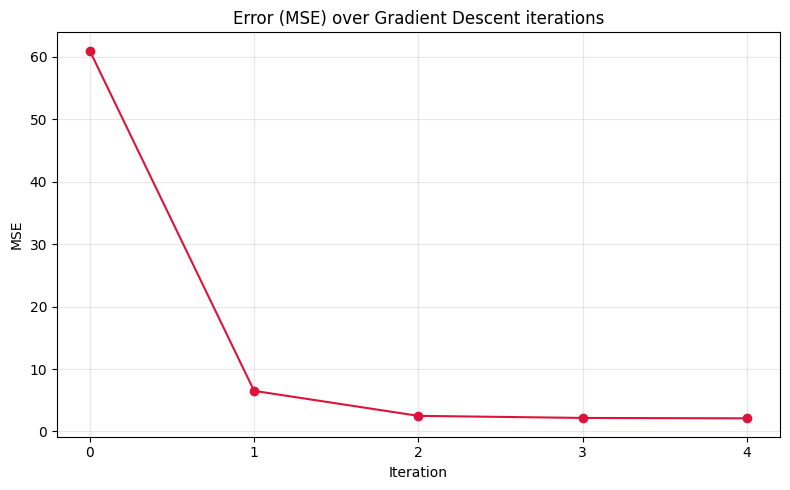

In [ ]:
# -*- coding: utf-8 -*-
"""
Part 4: Gradient Descent in Code

Converts the Part 3 manual calculations into Python.

Model (matrix form, NOT scalar-by-scalar):
    y_hat = X @ m + b
Cost function (Mean Squared Error):
    J(m, b) = (1/n) * sum( (y_hat - y)^2 )

Requirements covered:
  1. Same data / initial values as the Part 3 handwritten work.
  2. A SciPy-based function that accepts an equation (cost function)
     and computes its derivative (gradient) numerically.
  3. A training loop that updates m and b, printing EVERY intermediate
     step (predictions, errors, gradients, updated parameters).
  4. Predictions using the final m and b.
  5. Matplotlib: one plot for m & b over iterations, a separate plot
     for the error over iterations.

The numerical SciPy gradient is cross-checked at every iteration
against the analytical chain-rule gradient derived in Part 3:
    dJ/dm = (2/n) * X^T @ (y_hat - y)
    dJ/db = (2/n) * (y_hat - y)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

# ---------------------------------------------------------------
# 1. DATA + INITIAL PARAMETERS (exactly as given in Part 3)
# ---------------------------------------------------------------
X = np.array([[1.0, 3.0],
              [4.0, 10.0]])      # data points (x1, x2) per row
y = np.array([5.0, 6.0])         # targets

m = np.array([-1.0, 2.0])        # initial m = [m1, m2]
b = np.array([1.0, 1.0])         # initial b = [b1, b2]

n = len(y)                       # number of data points
learning_rate = 0.01             # <-- MUST match the alpha used in Part 3
n_iterations = 4                 # <-- one update per group member

# ---------------------------------------------------------------
# 2. MODEL + COST FUNCTION
# ---------------------------------------------------------------
def predict(X, m, b):
    """y_hat = X @ m + b  (matrix multiplication, not scalar ops)."""
    return X @ m + b

def mse_cost(X, y, m, b):
    """J(m, b) = mean of squared errors."""
    errors = predict(X, m, b) - y
    return np.mean(errors ** 2)

# ---------------------------------------------------------------
# 3. SCIPY DERIVATIVE FUNCTION (requirement: "accepts an equation
#    and computes its derivative")
# ---------------------------------------------------------------
def scipy_gradient(cost_fn, params, eps=1e-7):
    """
    Generic derivative helper.
    cost_fn : any function that takes a 1-D parameter vector -> scalar cost
    params  : the point at which to evaluate the gradient
    Returns the numerical gradient using SciPy's approx_fprime.
    """
    return approx_fprime(params, cost_fn, eps)

def packed_cost(theta):
    """Pack m and b into one vector theta = [m1, m2, b1, b2] so SciPy
    can differentiate the cost with respect to ALL parameters at once."""
    m_, b_ = theta[:2], theta[2:]
    return mse_cost(X, y, m_, b_)

# ---------------------------------------------------------------
# 4. ANALYTICAL GRADIENT (the Part 3 chain-rule result, used to
#    verify SciPy's numerical answer at every step)
# ---------------------------------------------------------------
def analytical_gradient(X, y, m, b):
    errors = predict(X, m, b) - y            # (y_hat - y)
    grad_m = (2.0 / n) * (X.T @ errors)      # dJ/dm  (chain rule)
    grad_b = (2.0 / n) * errors              # dJ/db  (chain rule)
    return grad_m, grad_b

# ---------------------------------------------------------------
# 5. GRADIENT DESCENT LOOP -- every calculation step is printed
# ---------------------------------------------------------------
history = {"m": [m.copy()], "b": [b.copy()],
           "error": [mse_cost(X, y, m, b)]}

print("=" * 70)
print(f"INITIAL STATE (Iteration 0)")
print(f"  m = {m},  b = {b}")
print(f"  y_hat = {predict(X, m, b)}")
print(f"  MSE   = {history['error'][0]:.6f}")
print("=" * 70)

for it in range(1, n_iterations + 1):
    # --- Step 1: forward pass (predictions) ---
    y_hat = predict(X, m, b)
    errors = y_hat - y

    # --- Step 2: derivative via SciPy (numerical) ---
    theta = np.concatenate([m, b])
    grad_num = scipy_gradient(packed_cost, theta)
    grad_m_num, grad_b_num = grad_num[:2], grad_num[2:]

    # --- Step 3: derivative via chain rule (verification) ---
    grad_m_ana, grad_b_ana = analytical_gradient(X, y, m, b)

    # --- Step 4: parameter update ---
    m = m - learning_rate * grad_m_num
    b = b - learning_rate * grad_b_num

    # --- Step 5: new cost ---
    error = mse_cost(X, y, m, b)
    history["m"].append(m.copy())
    history["b"].append(b.copy())
    history["error"].append(error)

    # --- Print every intermediate result ---
    print(f"\nITERATION {it}")
    print(f"  y_hat            = {y_hat}")
    print(f"  errors (y_hat-y) = {errors}")
    print(f"  dJ/dm (SciPy)    = {grad_m_num}")
    print(f"  dJ/dm (chain)    = {grad_m_ana}   <- should match")
    print(f"  dJ/db (SciPy)    = {grad_b_num}")
    print(f"  dJ/db (chain)    = {grad_b_ana}   <- should match")
    print(f"  updated m        = {m}")
    print(f"  updated b        = {b}")
    print(f"  MSE after update = {error:.6f}")

# ---------------------------------------------------------------
# 6. FINAL PREDICTIONS with the trained parameters
# ---------------------------------------------------------------
final_pred = predict(X, m, b)
print("\n" + "=" * 70)
print("FINAL PARAMETERS AND PREDICTIONS")
print(f"  final m = {m}")
print(f"  final b = {b}")
print(f"  predictions y_hat = {final_pred}")
print(f"  true values y     = {y}")
print(f"  final MSE         = {history['error'][-1]:.6f}")
print("=" * 70)

# ---------------------------------------------------------------
# 7. PLOTS
# ---------------------------------------------------------------
iters = np.arange(n_iterations + 1)
m_hist = np.array(history["m"])
b_hist = np.array(history["b"])

# Plot 1: how m and b change over iterations
plt.figure(figsize=(8, 5))
plt.plot(iters, m_hist[:, 0], marker="o", label="m1")
plt.plot(iters, m_hist[:, 1], marker="o", label="m2")
plt.plot(iters, b_hist[:, 0], marker="s", linestyle="--", label="b1")
plt.plot(iters, b_hist[:, 1], marker="s", linestyle="--", label="b2")
plt.xlabel("Iteration")
plt.ylabel("Parameter value")
plt.title("Evolution of m and b over Gradient Descent iterations")
plt.xticks(iters)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2 (separate): how the error changes over iterations
plt.figure(figsize=(8, 5))
plt.plot(iters, history["error"], marker="o", color="crimson")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Error (MSE) over Gradient Descent iterations")
plt.xticks(iters)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()